# One solve, many questions: `wrt=` blocks, prediction bands, `retain_kkt()`

When POUNCE solves a nonlinear program it builds and factorizes the
KKT matrix, the matrix of optimality conditions (short for
Karush-Kuhn-Tucker) that every uncertainty question afterwards is
answered against. The solve already paid for that factorization, so
asking it more questions is nearly free. `wrt=` points `covariance()`
and `information()` at any subset of the problem's variables (a
"block"), post-solve: a few of the fitted parameters, a predicted
trajectory, a question about what stays uncertain while a bound
holds. With `retain_kkt()` the factorization is kept even with
nothing declared, for problems where no subset is THE fitted set.

In [1]:
import warnings

import numpy as np
import matplotlib.pyplot as plt
import pyomo.environ as pyo

import pyomo_pounce
from pyomo_pounce import (
    covariance, declare_fitted, declare_residual, information,
    retain_kkt)

rng = np.random.default_rng(4)
A_TRUE, K_TRUE, SIG_TRUE = 2.0, 0.9, 0.05
t_data = np.linspace(0.0, 4.0, 30)
y_data = (A_TRUE * np.exp(-K_TRUE * t_data)
          + SIG_TRUE * rng.standard_normal(len(t_data)))


def build(t, y, declare=True):
    m = pyo.ConcreteModel()
    m.I = pyo.RangeSet(0, len(t) - 1)
    m.A = pyo.Var(initialize=1.0)
    m.k = pyo.Var(initialize=1.0)
    m.yhat = pyo.Var(m.I, initialize=1.0)
    m.r = pyo.Var(m.I, initialize=0.0)

    @m.Constraint(m.I)
    def prediction(mm, i):
        return mm.yhat[i] == mm.A * pyo.exp(-mm.k * float(t[i]))

    @m.Constraint(m.I)
    def residual(mm, i):
        return mm.r[i] == float(y[i]) - mm.yhat[i]

    m.obj = pyo.Objective(expr=sum(m.r[i] ** 2 for i in m.I))
    if declare:
        declare_fitted(m.A, m.k)
        declare_residual(m.r)
    return m

m = build(t_data, y_data)
pyo.SolverFactory("pounce").solve(m, tee=True)
cov = covariance(m)
print(f"A = {pyo.value(m.A):.4f} +/- {cov.std_err[m.A]:.4f}")
print(f"k = {pyo.value(m.k):.4f} +/- {cov.std_err[m.k]:.4f}")

********************************************************************************

                    ####    ###   /   # /#   #/  ####  #####
                    #   #  #   # /#   #/ ##  /  #      #
                    ####   #   #/ #   /  # #/#  #      ####
                    #      #   /  #  /#  # /##  #      #
                    #       ##/    #/#   #/  #   ####  #####

********************************************************************************
This program contains POUNCE, a pure-Rust interior-point optimization solver
for nonlinear, conic, and global problems (its NLP core is ported from Ipopt).
Released under the Eclipse Public License (EPL) — drop-in compatible with Ipopt.
         For more information visit https://github.com/jkitchin/pounce
********************************************************************************

This is POUNCE version 0.9.0, running with linear solver FERAL.



Number of nonzeros in equality constraint Jacobian...:      149
Number of nonzeros in inequality constraint Jacobian.:        0
Number of nonzeros in Lagrangian Hessian.............:       32

Total number of variables............................:       62
                     variables with only lower bounds:        0
                variables with lower and upper bounds:        0
                     variables with only upper bounds:        0
Total number of equality constraints.................:       60
Total number of inequality constraints...............:        0
        inequality constraints with only lower bounds:        0
   inequality constraints with lower and upper bounds:        0
        inequality constraints with only upper bounds:        0

iter      objective   inf_pr   inf_du lg(mu)    ||d|| lg(rg) alpha_du alpha_pr  ls
   0  0.0000000e+00 1.05e+00 0.00e+00   -1.0 0.00e+00      - 0.00e+00 0.00e+00   0
   1  9.3625449e-02 9.34e-02 3.32e-02   -1.0 9.97e-01      - 1.0

A = 2.0022 +/- 0.0365
k = 0.9077 +/- 0.0250


## 1. Sub-block marginals

Each `wrt=` call asks the same held factorization about a different
subset: one solve, as many questions as you like. The answer for a
block is its marginal uncertainty, with everything outside the block
allowed to adjust rather than held fixed. A sub-block's marginal
equals the corresponding entry of the default answer exactly, because
the noise level sigma is estimated once from the fit itself, dividing
by its degrees of freedom (data points minus fitted parameters), and
does not change with the question being asked.

In [2]:
cov_A = covariance(m, wrt=[m.A])
print(f"marginal via wrt=[A]: {cov_A[m.A]:.6g}")
print(f"entry of the default: {cov[m.A]:.6g}")
info_A = information(m, wrt=[m.A])
print(f"\ninformation marginal of A alone: {info_A[m.A]:.6g}")
print(f"sibling identity  cov*info = 2 sigma^2: "
      f"{cov_A[m.A] * info_A[m.A]:.6g} vs {2 * cov.sigma_sq:.6g}")

marginal via wrt=[A]: 0.00132948
entry of the default: 0.00132948

information marginal of A alone: 5.05951
sibling identity  cov*info = 2 sigma^2: 0.00672651 vs 0.00672651


## 2. The prediction band is a `wrt=` block

The model carries its predicted values as ordinary variables: each
`yhat[i]` is constrained to equal the curve at one data point, and
nothing at all was declared about them. `wrt=` can still ask about
them, and their covariance is exactly the uncertainty of the fitted
curve at the data points; plotting +/- 2 standard errors around the
fit gives the prediction band. This block has 30 coordinates while
the fit has only 2 free parameters, so its covariance has rank 2:
rank-deficient, carrying fewer independent directions than rows. That
is fine for a covariance, which is read directly off the inverse KKT
matrix with nothing inverted, and it is exactly why `information()`
refuses the same block: information would be the inverse of that
covariance, and a rank-deficient matrix has no inverse.

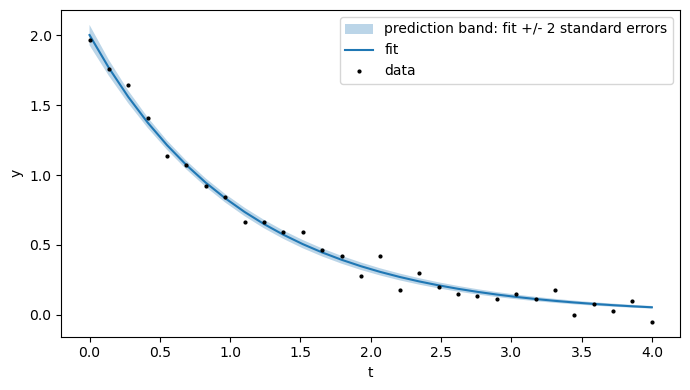

information(m, wrt=m.yhat) refuses:
  information: the wrt block is rank-deficient (more coordinates than the fit has degrees of freedom), so it carries no information matrix; its covariance (covariance(model, wrt=...)) is the meaningful object for such a block


In [3]:
band = covariance(m, wrt=m.yhat)
se = np.sqrt(np.diag(band.matrix))
fit = np.array([pyo.value(m.yhat[i]) for i in m.I])

plt.figure(figsize=(7, 4))
plt.fill_between(t_data, fit - 2 * se, fit + 2 * se,
                 alpha=0.3,
                 label="prediction band: fit +/- 2 standard errors")
plt.plot(t_data, fit, label="fit")
plt.plot(t_data, y_data, "k.", ms=4, label="data")
plt.xlabel("t"); plt.ylabel("y"); plt.legend(); plt.tight_layout()
plt.show()

try:
    information(m, wrt=m.yhat)
except RuntimeError as e:
    print("information(m, wrt=m.yhat) refuses:")
    print(" ", str(e))

## 3. `conditioned_on`: the answer's conditioning, returned

Pin `A` at a bound (a limit the solution presses against) and ask
about `k` alone. The block's number is the value conditional on that
bound, computed as if `A` were clamped there, not the marginal over
it. And the result SAYS so: the strongly active variables outside the
block come back on `conditioned_on`, so the conditioning travels with
the answer instead of living in the caller's head.

In [4]:
m2 = build(t_data, y_data)
m2.A.setlb(pyo.value(m.A) + 0.2)
with warnings.catch_warnings(record=True):
    warnings.simplefilter("always")
    pyo.SolverFactory("pounce").solve(m2)
cov_k = covariance(m2, wrt=[m2.k])
print(f"var(k) conditional on the bound: {cov_k[m2.k]:.6g}")
print("conditioned on:", [v.name for v in cov_k.conditioned_on])

var(k) conditional on the bound: 0.000821034
conditioned on: ['A']


Conditioning is visible in the band. Recompute the prediction band on
the pinned solve: with `A` held by its bound, the remaining
uncertainty comes from `k` alone, and the band tightens most where `A`
dominated the curve, near $t = 0$.

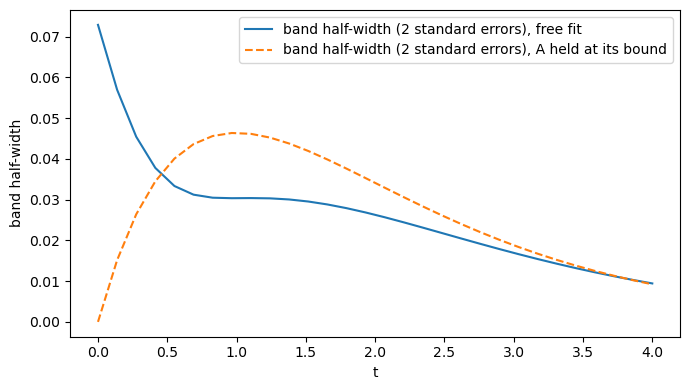

conditioned on: ['A']


In [5]:
band_pin = covariance(m2, wrt=m2.yhat)
se_pin = np.sqrt(np.diag(band_pin.matrix))

plt.figure(figsize=(7, 4))
plt.plot(t_data, 2 * se,
         label="band half-width (2 standard errors), free fit")
plt.plot(t_data, 2 * se_pin, "--",
         label="band half-width (2 standard errors), A held at its bound")
plt.xlabel("t"); plt.ylabel("band half-width")
plt.legend(); plt.tight_layout()
plt.show()
print("conditioned on:", [v.name for v in band_pin.conditioned_on])

## 4. `retain_kkt()`: the declaration-free flow

This pattern comes from moving horizon estimation (MHE), a control
method that re-solves an estimation problem every few seconds. There,
no single set of variables is THE fitted set: one moment you ask about
the current state estimate, the next about the model parameters, each
with its own `wrt=`. `retain_kkt(model)` keeps the factorization with
no declaration at all; `covariance(model)` without a block stays an
error, since there is no default to reduce onto, and a solve without
the call and without declarations pays nothing, exactly as before.

In [6]:
m3 = build(t_data, y_data, declare=False)
retain_kkt(m3)
pyo.SolverFactory("pounce").solve(m3)

s2 = float(cov.sigma_sq)          # noise from the declared fit above
info_params = information(m3, wrt=[m3.A, m3.k])
print("parameter information via retain_kkt only:")
print(np.array2string(info_params.matrix, precision=3))

band3 = covariance(m3, sigma_sq=s2, wrt=m3.yhat)
print()
print("band from the undeclared solve matches:",
      f"{np.max(np.abs(band3.matrix - band.matrix)):.2e}")

try:
    covariance(m3, sigma_sq=s2)
except RuntimeError as e:
    print()
    print("covariance(m3) without wrt refuses:")
    print(" ", str(e))

parameter information via retain_kkt only:
[[ 9.024 -8.718]
 [-8.718 19.169]]

band from the undeclared solve matches: 0.00e+00

covariance(m3) without wrt refuses:
  covariance: no fitted parameters were declared; flag the fitted variables with declare_fitted() before the solve, or select a block explicitly with wrt=


One policy covers retention: the factorization is kept if
anything is declared or `retain_kkt()` was called; a result object
whose lazy `conditioned_on` has not been read keeps the session alive
until first access; and an undeclared solve without the call pays
nothing.